# film revenue prediction - project notebook

## sections
1. project overview
2. data acquisition
3. pre-cleaning eda
4. data merging
5. data cleaning
6. post-cleaning eda
7. train / val / test split
8. data leakage analysis
9. feature engineering
10. multimodal fusion
11. baseline model
12. evaluation metrics
13. model selection + hyperparameter tuning
14. ablation study
15. fine-tuning experiment
16. interpretability with shap
17. report-ready outputs
18. pitfalls checklist

In [2]:
# setup
import os
import ast
import json
import requests
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torchvision.models as models
import torchvision.transforms as transforms

from sentence_transformers import SentenceTransformer

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

## 1) project overview

### 1.1 central research question
- what matters more for pre-release prediction: feature representation or model choice?

### 1.2 prediction target
- primary target: `y = log1p(revenue)`
- derived label: `profitable = 1[revenue > 1.5 * budget]`

### 1.3 core thesis
- combining structured metadata + synopsis embeddings + poster embeddings should outperform any single modality.

## 2) data acquisition

### 2.1 tmdb (kaggle)
- `TMDB_movie_dataset_v11.csv`

### 2.2 imdb non-commercial files
- `title.crew.tsv.csv` (gzipped)
- `title.principals.tsv.csv` (gzipped)
- `name.basics.tsv.csv` (gzipped)

### 2.3 poster images
- build url: `https://image.tmdb.org/t/p/w342/{poster_path}`
- cache locally before embedding extraction

In [3]:
# load raw datasets
TMDB_PATH       = ROOT / "data/raw/TMDB_movie_dataset_v11.csv"
CREW_PATH       = ROOT / "data/raw/title.crew.tsv.csv"
PRINCIPALS_PATH = ROOT / "data/raw/title.principals.tsv.csv"
NAMES_PATH      = ROOT / "data/raw/name.basics.tsv.csv"


tmdb       = pd.read_csv(TMDB_PATH)
crew       = pd.read_csv(CREW_PATH,       sep='\t', low_memory=False)
principals = pd.read_csv(PRINCIPALS_PATH, sep='\t', low_memory=False)
names      = pd.read_csv(NAMES_PATH,      sep='\t', low_memory=False)

print(f"tmdb:       {tmdb.shape}")
print(f"crew:       {crew.shape}")
print(f"principals: {principals.shape}")
print(f"names:      {names.shape}")
tmdb.head()

tmdb:       (1419084, 24)
crew:       (12485800, 3)
principals: (99326376, 6)
names:      (15306875, 6)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## 3) pre-cleaning eda

- run quick diagnostics on raw tmdb data before merging/cleaning
- check missingness and duplicates to guide cleaning rules
- inspect budget/revenue outliers on released titles


### pre-cleaning frame

create a raw tmdb copy so checks are isolated and reproducible.


In [4]:
# pre-cleaning frame from raw tmdb table
pre_df = tmdb.copy()
print(f"raw tmdb shape: {pre_df.shape}")


raw tmdb shape: (1419084, 24)


### missing values

inspect missingness first to justify later filtering and imputation decisions.


In [5]:
# missing values check (top columns)
missing_pct = pre_df.isna().mean().sort_values(ascending=False) * 100
print("missing values (%), top 20 columns:")
print(missing_pct.head(20).round(2))


missing values (%), top 20 columns:
homepage                89.72
tagline                 86.08
keywords                75.28
backdrop_path           75.16
production_companies    57.43
imdb_id                 52.93
production_countries    48.40
spoken_languages        46.47
genres                  43.95
poster_path             35.55
overview                22.94
release_date            22.24
title                    0.00
original_title           0.00
vote_average             0.00
vote_count               0.00
revenue                  0.00
popularity               0.00
runtime                  0.00
original_language        0.00
dtype: float64


### duplicates

measure duplicate risk to avoid training bias from repeated records.


In [6]:
# duplicates check
print(f"duplicate rows (full row): {pre_df.duplicated().sum():,}")
print(f"duplicate tmdb id:         {pre_df.duplicated(subset=["id"]).sum():,}")
print(f"duplicate imdb_id (non-null): {pre_df[pre_df["imdb_id"].notna() & (pre_df["imdb_id"] != "")].duplicated(subset=["imdb_id"]).sum():,}")


duplicate rows (full row): 381
duplicate tmdb id:         1,241
duplicate imdb_id (non-null): 3,968


### financial outliers

visualize budget and revenue tails before cleaning thresholds are applied.


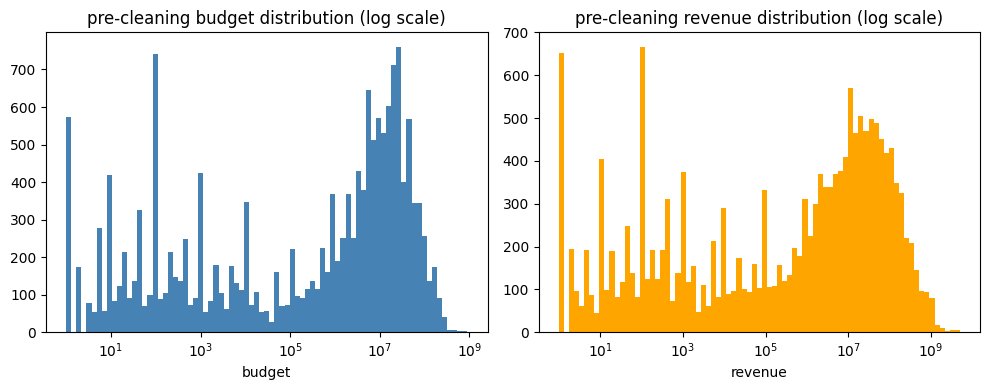

In [7]:
# outlier check before cleaning (released titles with positive financials)
pre_outlier = pre_df[(pre_df["status"] == "Released") & (pre_df["budget"].fillna(0) > 0) & (pre_df["revenue"].fillna(0) > 0)].copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(pre_outlier["budget"], bins=np.logspace(np.log10(pre_outlier["budget"].min()), np.log10(pre_outlier["budget"].max()), 80), color="steelblue")
ax[0].set_xscale("log")
ax[0].set_title("pre-cleaning budget distribution (log scale)")
ax[0].set_xlabel("budget")

ax[1].hist(pre_outlier["revenue"], bins=np.logspace(np.log10(pre_outlier["revenue"].min()), np.log10(pre_outlier["revenue"].max()), 80), color="orange")
ax[1].set_xscale("log")
ax[1].set_title("pre-cleaning revenue distribution (log scale)")
ax[1].set_xlabel("revenue")

plt.tight_layout()
plt.show()


### runtime distribution

check runtime spread and long tails that can affect model scaling.


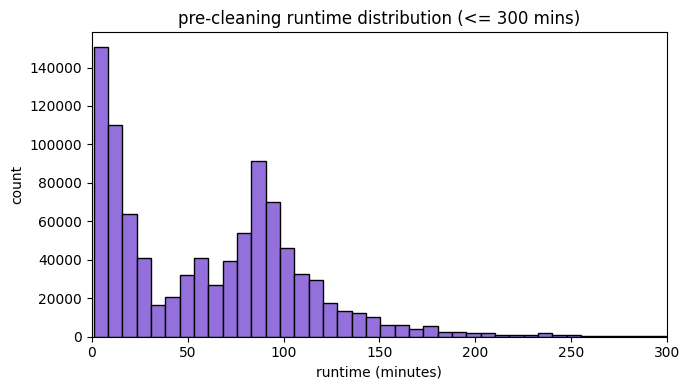

shown rows (<=300 mins): 957,841 / 961,797


In [8]:
# runtime distribution (released titles with valid runtime)
pre_runtime = pre_df[(pre_df["status"] == "Released") & (pre_df["runtime"].fillna(0) > 0)].copy()

# keep a realistic range for visualization only (does not alter the dataset)
runtime_plot = pre_runtime[pre_runtime["runtime"] <= 300]["runtime"]

plt.figure(figsize=(7, 4))
plt.hist(runtime_plot, bins=40, edgecolor="k", color="mediumpurple")
plt.title("pre-cleaning runtime distribution (<= 300 mins)")
plt.xlabel("runtime (minutes)")
plt.ylabel("count")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

print(f"shown rows (<=300 mins): {len(runtime_plot):,} / {len(pre_runtime):,}")


### language distribution

review language imbalance to guide category grouping later.


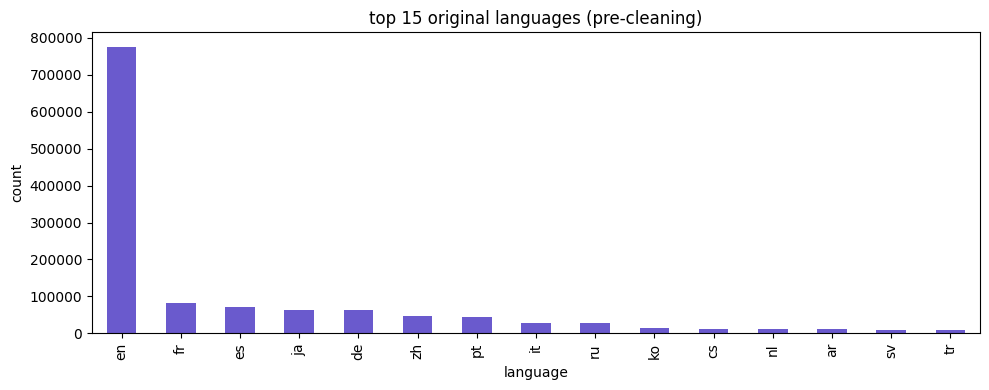

In [9]:
# top original languages
lang_counts = pre_df["original_language"].fillna("unknown").value_counts().head(15)

plt.figure(figsize=(10, 4))
lang_counts.plot(kind="bar", color="slateblue")
plt.title("top 15 original languages (pre-cleaning)")
plt.xlabel("language")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### top production countries

identify dominant producing countries to capture dataset concentration.


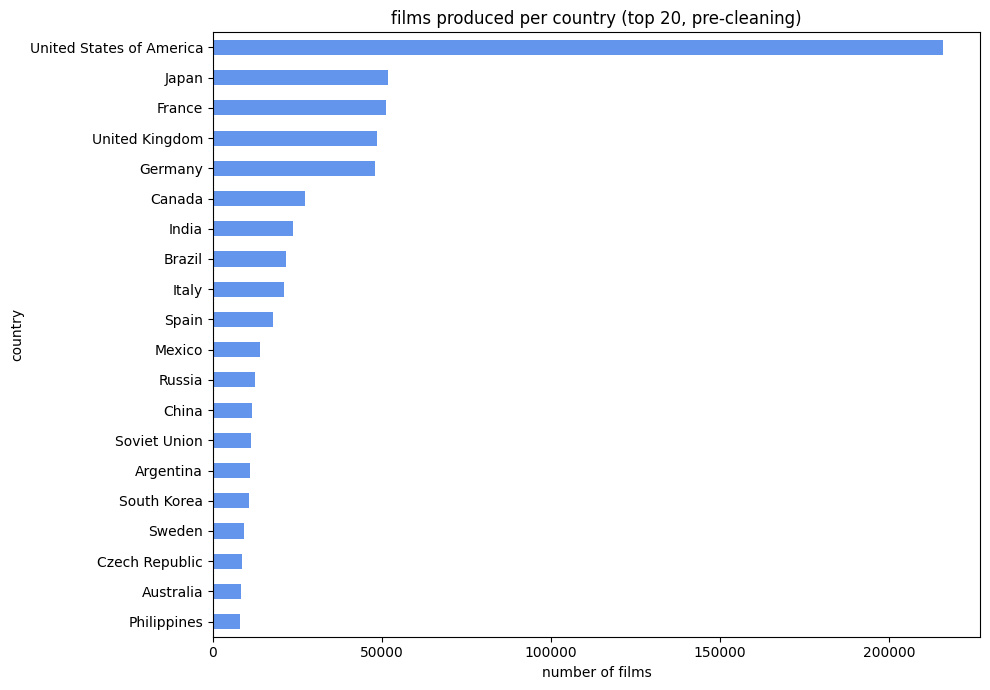

In [10]:
# parse the comma-separated production_countries string into a list per row
production_country_list = pre_df["production_countries"].fillna("").str.split(", ")

# films produced per country
country_counts = production_country_list.explode().dropna()
country_counts = country_counts[country_counts != ""]
country_counts = country_counts.value_counts()

if country_counts.empty:
    print("no production country entries were parsed from the current data sample.")
else:
    top_country_counts = country_counts.head(20).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    top_country_counts.plot(kind="barh", color="cornflowerblue")
    plt.title("films produced per country (top 20, pre-cleaning)")
    plt.xlabel("number of films")
    plt.ylabel("country")
    plt.tight_layout()
    plt.show()


### pre-cleaning eda conclusions

- the raw tmdb table has meaningful missingness in key fields, so cleaning and validity filters are necessary.
- duplicates exist and should be removed using stable ids to avoid biasing the model.
- budget and revenue show heavy right-skew with a low-value cluster, supporting log transforms and minimum-value filtering.
- runtime is also right-skewed, so robust scaling/log-style transforms can improve stability.
- language and production-country distributions are long-tailed, so rare-category grouping should be considered during feature engineering.


## 4) data merging

- use tmdb as base table
- join tmdb `imdb_id` to imdb `tconst`
- keep join diagnostics: row counts and match rate

> note: TMDB v11 has ~1.4M rows including TV/shorts — low overall match rate is expected.
> match rate on movies with valid budget+revenue (after section 5) will be much higher.

In [11]:
## 4.1 merge tmdb + crew (directors & writers)
# tmdb is the base table; crew adds director/writer nconst lists per title
base = tmdb.copy()
n_base = len(base)

crew_small = crew[["tconst", "directors", "writers"]].copy()

# left join so all tmdb rows are kept; unmatched rows get NaN for crew columns
merged = base.merge(crew_small, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)  # redundant after join

crew_match = merged["directors"].notna().mean()
print(f"tmdb rows:        {n_base:,}")
print(f"after crew join:  {len(merged):,}")
print(f"crew match rate:  {crew_match:.2%}")  # low overall because ~53% of tmdb rows have no imdb_id

## 4.2 merge top-billed cast from principals
# principals is many-to-one (many cast members per title), so we aggregate first
# keep only actors/actresses ranked 1-3 to avoid exploding rows on join
cast = (
    principals[principals["category"].isin(["actor", "actress"])]
    .sort_values("ordering")
    .groupby("tconst")
    .head(3)
)

# pivot long → wide so each title gets one row with cast_1, cast_2, cast_3 nconst ids
cast["rank"] = cast.groupby("tconst").cumcount() + 1
cast_wide = (
    cast.pivot(index="tconst", columns="rank", values="nconst")
    .rename(columns={1: "cast_1", 2: "cast_2", 3: "cast_3"})
    .reset_index()
)

merged = merged.merge(cast_wide, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)

cast_match = merged["cast_1"].notna().mean()
print(f"after cast join:  {len(merged):,}")
print(f"cast match rate:  {cast_match:.2%}")  # ~81% among rows with imdb_id

## 4.3 resolve nconst → name for director and top cast
# nconst are opaque ids; map them to human-readable names for EDA and features
name_map = names.set_index("nconst")["primaryName"]

def resolve_names(nconst_series):
    return nconst_series.map(name_map)

# directors field can contain a comma-separated list; take only the first (primary) director
merged["director_name"] = resolve_names(merged["directors"].str.split(",").str[0])
merged["cast_1_name"]   = resolve_names(merged["cast_1"])
merged["cast_2_name"]   = resolve_names(merged["cast_2"])
merged["cast_3_name"]   = resolve_names(merged["cast_3"])

print(f"\nfinal shape: {merged.shape}")
merged[["title", "imdb_id", "director_name", "cast_1_name", "cast_2_name", "cast_3_name"]].head()

tmdb rows:        1,419,084
after crew join:  1,419,084
crew match rate:  46.82%
after cast join:  1,419,084
cast match rate:  38.13%

final shape: (1419084, 33)


,title,imdb_id,director_name,cast_1_name,cast_2_name,cast_3_name
0,Inception,tt1375666,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page
1,Interstellar,tt0816692,Christopher Nolan,Matthew McConaughey,Anne Hathaway,Jessica Chastain
2,The Dark Knight,tt0468569,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart
3,Avatar,tt0499549,James Cameron,Sam Worthington,Zoe Saldaña,Sigourney Weaver
4,The Avengers,tt0848228,Joss Whedon,Robert Downey Jr.,Robert Downey Jr.,Chris Evans


In [12]:
# diagnose: how many tmdb rows actually have an imdb_id?
has_imdb = tmdb["imdb_id"].notna() & (tmdb["imdb_id"] != "")
print(f"tmdb rows with imdb_id:    {has_imdb.sum():,} / {len(tmdb):,} ({has_imdb.mean():.2%})")

# of those, how many matched crew?
has_imdb_merged = merged["imdb_id"].notna() & (merged["imdb_id"] != "")
crew_matched = merged["directors"].notna()
print(f"crew match rate (with id): {(crew_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

cast_matched = merged["cast_1"].notna()
print(f"cast match rate (with id): {(cast_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

tmdb rows with imdb_id:    667,999 / 1,419,084 (47.07%)
crew match rate (with id): 99.47%
cast match rate (with id): 81.01%


## 5) data cleaning

- remove invalid/missing budget or revenue rows
- parse dates and normalize schema
- define train-ready base table

### diagnose missing financial data

this quick diagnostic checks missingness patterns in unreleased titles and explains why they should be filtered before modeling.

In [13]:
# display missingness data for columns on the merged table to justify cleaning decisions. 

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = merged[merged["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 

# discover anomalies in financial indicators data (budget and revenue)



Percentage of unreleased titles with missing revenue data: 
revenue
0          0.992605
1          0.000789
100        0.000526
20         0.000292
10         0.000292
             ...   
8000000    0.000029
900        0.000029
120        0.000029
65         0.000029
67565      0.000029
Name: count, Length: 105, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0           0.904098
100         0.004647
1000        0.004355
500         0.004238
5000        0.003391
              ...   
23914       0.000029
15400000    0.000029
3600000     0.000029
22800000    0.000029
80876       0.000029
Name: count, Length: 685, dtype: float64


### scope the modeling population

this step keeps only released, non-adult films so the model learns from a consistent population with observable outcomes.

In [14]:
df = merged.copy()
print(f"start:                    {len(df):,}")

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = df[df["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 


# keep only released films --> TMDB includes upcoming, in-production, and cancelled
# titles which have no revenue by definition and would just be noise
df = df[df["status"] == "Released"]
print(f"after status filter:      {len(df):,}")

# drop adult content —-> adult films follow different market dynamics and mixing
# them in would hurt the model's ability to learn patterns for mainstream movies
df = df[df["adult"] == False]
print(f"after adult filter:       {len(df):,}")

start:                    1,419,084
Percentage of unreleased titles with missing revenue data: 
revenue
0          0.992605
1          0.000789
100        0.000526
20         0.000292
10         0.000292
             ...   
8000000    0.000029
900        0.000029
120        0.000029
65         0.000029
67565      0.000029
Name: count, Length: 105, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0           0.904098
100         0.004647
1000        0.004355
500         0.004238
5000        0.003391
              ...   
23914       0.000029
15400000    0.000029
3600000     0.000029
22800000    0.000029
80876       0.000029
Name: count, Length: 685, dtype: float64
after status filter:      1,368,369
after adult filter:       1,228,168


### keep valid financial signals

this step removes missing-placeholder values and implausibly small numbers to reduce financial noise in training data.

after budget/rev > 0:     16,664


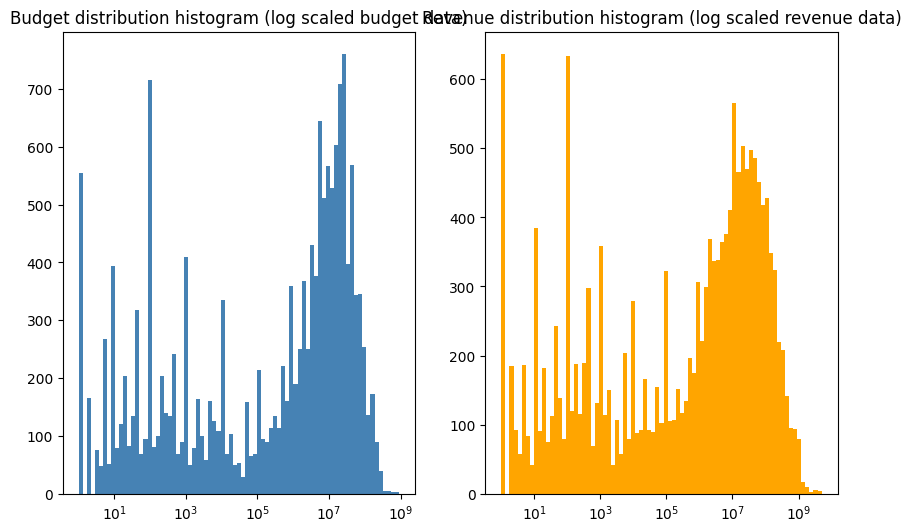

after min $10k filter:    10,655


In [15]:
# require valid budget and revenue --> TMDB uses 0 as a placeholder for "unknown",
# not an actual value, so 0 means missing data rather than a real zero
df = df[df["budget"].fillna(0) > 0]
df = df[df["revenue"].fillna(0) > 0]
print(f"after budget/rev > 0:     {len(df):,}")


# identify significant outliers in budget and revenue so as to justify the minimum $10k filter below 
# data in several orders of magnitude, so to make histogram bins readable, use a log spaced histogram.
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].hist(df["budget"], bins = np.logspace(np.log10(df["budget"].min()), np.log10(df["budget"].max()), 80), color = "steelblue")
ax[0].set_xscale("log")
ax[0].set_title("Budget distribution histogram (log scaled budget data)")
ax[1].hist(df["revenue"], bins = np.logspace(np.log10(df["revenue"].min()), np.log10(df["revenue"].max()), 80), color = "orange")
ax[1].set_xscale("log")
ax[1].set_title("Revenue distribution histogram (log scaled revenue data)")
plt.show()
# the two graphs show a cluster of entries with very low budget and revenue figures, which are likely to be data entry errors. 
# for example, there are around 550 entries with $1 budget. This is highly implausible.


# drop implausibly small values —-> entries like $1 budget or $500 revenue are
# clearly data entry errors; $10k is a conservative lower bound for any real
# theatrical release worth modeling
df = df[(df["budget"] >= 10_000) & (df["revenue"] >= 10_000)]
print(f"after min $10k filter:    {len(df):,}")

### enforce structural completeness

this step ensures required fields exist for downstream features and avoids duplicate movie entries.

In [16]:
# parse and require a valid release date —-> release timing is used as a feature
# (season, year) and is also needed for the temporal cutoff in talent features
# (section 5), so rows without a date can't be used
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
print(f"after date filter:        {len(df):,}")

# drop duplicates on tmdb id —-> some titles appear more than once in TMDB
# (e.g. different regional entries); keep first to avoid inflating the training set
df = df.drop_duplicates(subset=["id"])
print(f"after dedup:              {len(df):,}")

# require a non-empty overview —-> synopsis embeddings are a planned feature group
# (section 5); rows with no overview can't contribute to that modality so we
# drop them now rather than impute
df = df[df["overview"].fillna("").str.strip() != ""]
print(f"after overview filter:    {len(df):,}")

after date filter:        10,149
after dedup:              10,149
after overview filter:    9,950


### define supervised targets

this step creates the final regression and classification targets used by later modeling sections.

In [17]:
# define targets
df["y_log_revenue"] = np.log1p(df["revenue"])
df["profitable"]    = (df["revenue"] > 1.5 * df["budget"]).astype(int)

print(f"\nfinal clean shape: {df.shape}")
print(f"profitable share:  {df['profitable'].mean():.2%}")
df[["title", "release_date", "budget", "revenue", "y_log_revenue", "profitable"]].head()


final clean shape: (9950, 35)
profitable share:  55.88%


,title,release_date,budget,revenue,y_log_revenue,profitable
0,Inception,2010-07-15,160000000,825532764,20.531540,1
1,Interstellar,2014-11-05,165000000,701729206,20.369058,1
2,The Dark Knight,2008-07-16,185000000,1004558444,20.727814,1
3,Avatar,2009-12-15,237000000,2923706026,21.796118,1
4,The Avengers,2012-04-25,220000000,1518815515,21.141197,1


## 6) post-cleaning eda

- validate distributions and relationships on the cleaned modeling dataframe
- this section must run after section 5 (data cleaning)
- eda is intentionally performed on the full cleaned `df` before the train/val/test split: because the split is temporal (sorted by release_date, not random), looking at full-dataset distributions does not leak information about split boundaries — no distribution shift is introduced by this ordering
- this placement also allows catching any remaining data quality issues before committing to the split


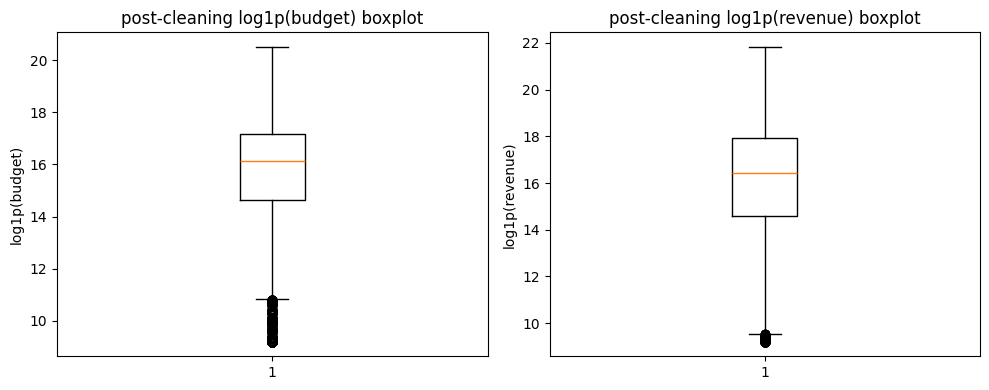

In [18]:
# outlier check after cleaning
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(np.log1p(df["budget"]))
ax[0].set_title("post-cleaning log1p(budget) boxplot")
ax[0].set_ylabel("log1p(budget)")

ax[1].boxplot(df["y_log_revenue"])
ax[1].set_title("post-cleaning log1p(revenue) boxplot")
ax[1].set_ylabel("log1p(revenue)")

plt.tight_layout()
plt.show()


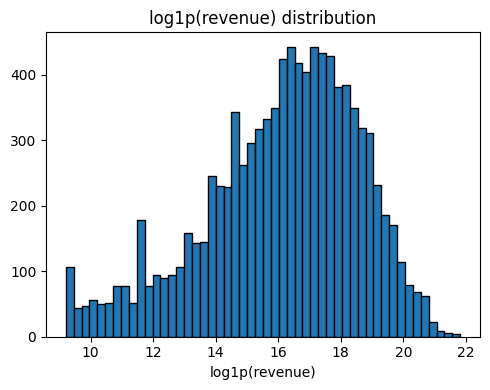

In [19]:
# post-cleaning distribution checks on clean df
plt.figure(figsize=(5, 4))
plt.hist(df["y_log_revenue"], bins=50, edgecolor='k')
plt.title("log1p(revenue) distribution")
plt.xlabel("log1p(revenue)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_revenue_distribution.png", dpi=100)
plt.show()


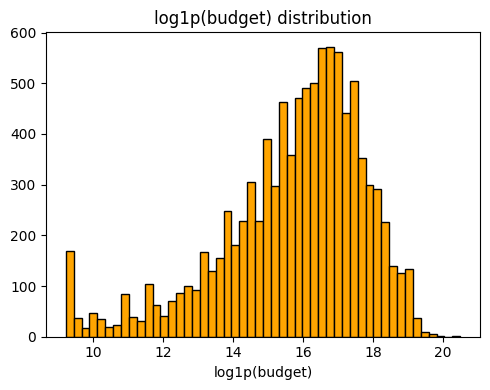

In [20]:
plt.figure(figsize=(5, 4))
plt.hist(np.log1p(df["budget"]), bins=50, edgecolor='k', color='orange')
plt.title("log1p(budget) distribution")
plt.xlabel("log1p(budget)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_budget_distribution.png", dpi=100)
plt.show()


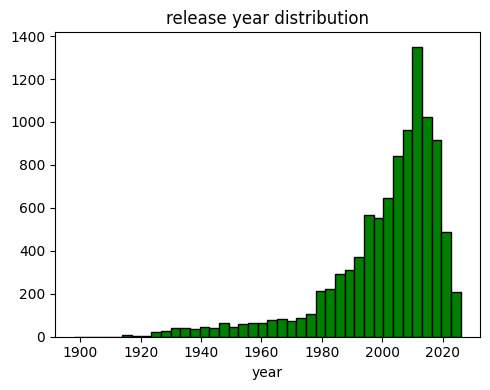

In [21]:
df["release_year"] = df["release_date"].dt.year

plt.figure(figsize=(5, 4))
plt.hist(df["release_year"], bins=40, edgecolor='k', color='green')
plt.title("release year distribution")
plt.xlabel("year")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_release_year_distribution.png", dpi=100)
plt.show()


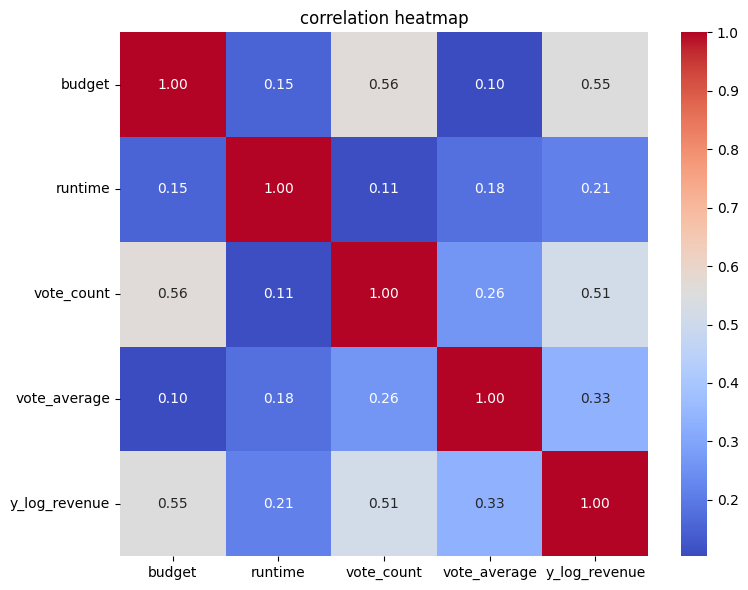

In [22]:
# correlation heatmap — vote columns included here for eda only, not used as features
numeric_cols = ["budget", "runtime", "vote_count", "vote_average", "y_log_revenue"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_correlation.png", dpi=100)
plt.show()


In [23]:
# analysis of relationships between genres and revenue
# genre frequency
df_genres = df.copy() # create a copy of the dataframe for analysis on relationships between genres and other variables
df_genres.dropna(subset = ["genres"], inplace = True)
# find the number of genres that each movie has
df_genres["num_genres"] = df_genres["genres"].str.split(", ").str.len()
# explode the genres column
df_genres["genres"] = df_genres["genres"].str.split(", ")
df_genres = df_genres.explode("genres")
genre_counts = df_genres["genres"].value_counts().head(15)
print("top 15 genres:")
print(genre_counts)

# correlation between genre and revenue for the top 5 genres
# discover whether certain genres tend to have higher revenues
top_genres = genre_counts.head(5).index.tolist()
rows_top_genres = df_genres[df_genres["genres"].isin(top_genres)] # we are interested in finding the movies that belong to the top genres


top 15 genres:
genres
Drama              4623
Comedy             3511
Action             2376
Thriller           2325
Romance            1876
Adventure          1623
Crime              1458
Horror             1094
Family              996
Science Fiction     962
Fantasy             907
Mystery             798
Animation           562
History             507
Music               407
Name: count, dtype: int64


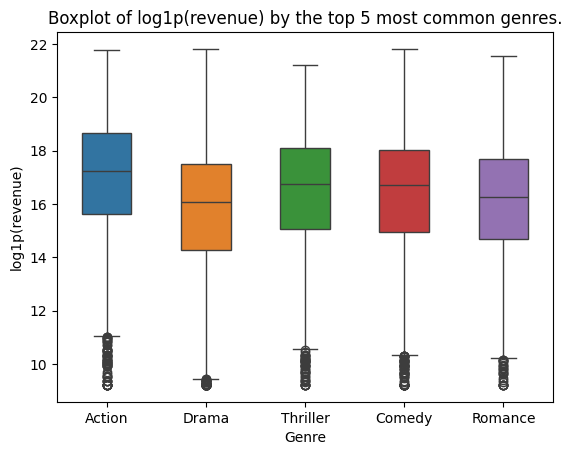

In [24]:
sns.boxplot(data = rows_top_genres, x = "genres", y = "y_log_revenue", hue = "genres", width = 0.5)
plt.title("Boxplot of log1p(revenue) by the top 5 most common genres.")
plt.xlabel("Genre")
plt.ylabel("log1p(revenue)")
plt.show()
# it can be shown that the action genre has the highest 25th percentile, median, and 75th percentile.
# it is likely that the action genre is the most profitable genre on average. there is a potential link between genre and revenue.


In [25]:
# relationships between number of genres and revenue
print("Count of movies by number of genres: ")
print(df_genres["num_genres"].value_counts())
# discover whether the number of genres a movie belongs to will result in an impact on revenue.


Count of movies by number of genres: 
num_genres
3     10095
2      6598
4      4404
1      1747
5      1545
6       294
7        70
11       11
8         8
Name: count, dtype: int64


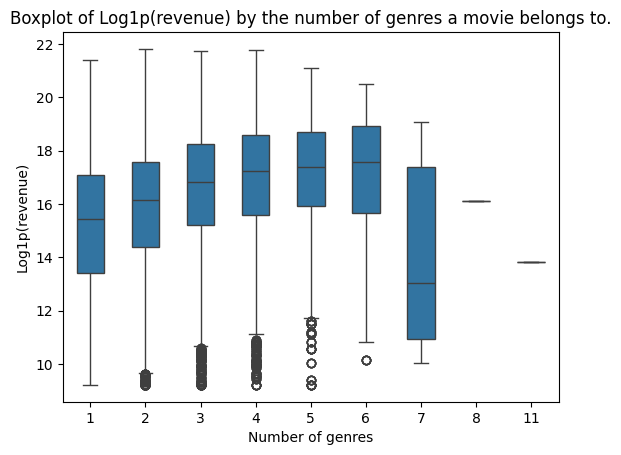

In [26]:
sns.boxplot(data = df_genres, x = "num_genres", y = "y_log_revenue", width = 0.5)
plt.title("Boxplot of Log1p(revenue) by the number of genres a movie belongs to.")
plt.xlabel("Number of genres")
plt.ylabel("Log1p(revenue)")
plt.show()
# up till number of genres = 6, there is a general trend of increasing revenue
# the huge interval between the median and the 75th percentile for genres = 7 is likely due to the fact that there is a small number of movies (70) in total, with some very high earners.
# ignore the movies with > 7 genres since they are outliers and there are very few movies with that many genres.
# overall, the number of genres a movie has seems to be informative, as it can reflect a movie being marketed to a wide range of audiences, stronger push and marketing, etc.


## 7) train / val / test split

split after all cleaning and post-cleaning eda steps.


In [27]:
# sort by release date so older films train the model and newer films test it
df_sorted = df.sort_values("release_date").reset_index(drop=True)

n         = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_sorted.iloc[:train_end].copy()
val_df   = df_sorted.iloc[train_end:val_end].copy()
test_df  = df_sorted.iloc[val_end:].copy()

print(f"train: {len(train_df):,}  ({train_df['release_date'].min().year}–{train_df['release_date'].max().year})")
print(f"val:   {len(val_df):,}  ({val_df['release_date'].min().year}–{val_df['release_date'].max().year})")
print(f"test:  {len(test_df):,}  ({test_df['release_date'].min().year}–{test_df['release_date'].max().year})")

train: 6,965  (1898–2012)
val:   1,492  (2012–2017)
test:  1,493  (2017–2026)


## 8) data leakage analysis

- define the pre-release information boundary
- columns like `vote_average`, `vote_count`, `popularity` reflect post-release audience response — exclude from main features
- run a leakage demonstration: train with vs without these columns to quantify their inflation effect

In [28]:
# columns known before a film's release date — safe to use as features
PRE_RELEASE_COLS = [
    "budget", "runtime", "original_language",
    "genres", "production_companies", "production_countries",
    "release_date",   # used to derive timing features
    "overview",       # for synopsis embeddings
    "poster_path",    # for poster embeddings
    "director_name", "cast_1_name", "cast_2_name", "cast_3_name",
    "directors", "cast_1", "cast_2", "cast_3",
]

# only known after release — must not be used as predictive features
POST_RELEASE_COLS = ["vote_average", "vote_count", "popularity"]

print("post-release columns excluded from main feature set:")
for col in POST_RELEASE_COLS:
    print(f"  {col}")

# leakage demonstration: compare r2 with and without post-release columns
demo_safe   = ["budget", "runtime"]
demo_leaked = ["budget", "runtime", "vote_count", "vote_average", "popularity"]

def demo_r2(cols):
    _train = train_df[cols + ["y_log_revenue"]].dropna()
    _val   = val_df[cols + ["y_log_revenue"]].dropna()
    model  = Ridge().fit(_train[cols], _train["y_log_revenue"])
    return r2_score(_val["y_log_revenue"], model.predict(_val[cols]))

print(f"\nr2 without leakage cols: {demo_r2(demo_safe):.3f}")
print(f"r2 WITH leakage cols:    {demo_r2(demo_leaked):.3f}")
print("→ inflated r2 confirms these are post-release signals, not predictive features")

post-release columns excluded from main feature set:
  vote_average
  vote_count
  popularity

r2 without leakage cols: 0.358
r2 WITH leakage cols:    0.475
→ inflated r2 confirms these are post-release signals, not predictive features


## 9) feature engineering

### 9.1 structured metadata
- `log_budget`: log1p-transforms budget to compress the heavy right tail and linearise the budget–revenue relationship
- `runtime`: missing values imputed with the train-set median (zero-fill would create a spurious "no-runtime" signal)
- `release_month`, `release_year`: capture seasonal box-office patterns and inflation/market-growth trends over time
- `is_english`: binary flag — english is the dominant language category (>50 % of training titles); full cardinality encoding adds noise for rare languages
- `is_us_production`: binary flag — us productions dominate the dataset and sit in systematically higher revenue brackets (confirmed in eda, section 3)
- `num_genres`: count of genres per title — eda (section 6) showed a positive trend with revenue up to ~6 genres, likely reflecting wider audience targeting and larger marketing pushes


In [29]:
# scaler is fit on train only — applying to val/test avoids leaking their distribution statistics

# impute missing runtime with the train-set median before scaling:
# fillna(0) would introduce a spurious "zero-runtime" bin that tree models would split on;
# the median is a robust central estimate that keeps the imputed value in the distribution core
train_median_runtime = train_df["runtime"].median()
for split in [train_df, val_df, test_df]:
    split["runtime"] = split["runtime"].fillna(train_median_runtime)

for split in [train_df, val_df, test_df]:
    # log1p compresses the multi-order-of-magnitude budget range and linearises
    # the relationship with log-revenue (both are now roughly on the same scale)
    split["log_budget"] = np.log1p(split["budget"])

    split["release_month"] = split["release_date"].dt.month
    # release_year already on df from the eda cell (cell 39) — no need to recompute

    # binary english flag rather than full language one-hot: english accounts for >50% of
    # training titles and is the dominant revenue-correlated category; encoding all rare
    # languages individually would add noise with minimal signal
    split["is_english"] = (split["original_language"] == "en").astype(int)

    # us productions dominate the dataset and sit in higher revenue brackets (see eda);
    # a binary flag captures this cleanly without encoding the full country list
    split["is_us_production"] = (
        split["production_countries"].fillna("").str.contains("United States of America", regex=False)
    ).astype(int)

    # genre count: eda (section 6) showed revenue increases monotonically up to ~6 genres;
    # wider genre coverage likely reflects larger marketing scope and audience targeting
    split["num_genres"] = split["genres"].fillna("").apply(
        lambda x: len(x.split(", ")) if x.strip() else 0
    )

structured_cols = [
    "log_budget", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres",
]

scaler_struct  = StandardScaler()
X_struct_train = scaler_struct.fit_transform(train_df[structured_cols])
X_struct_val   = scaler_struct.transform(val_df[structured_cols])
X_struct_test  = scaler_struct.transform(test_df[structured_cols])

print(f"9.1 structured features: {X_struct_train.shape}")
print(f"  cols: {structured_cols}")

9.1 structured features: (6965, 7)
  cols: ['log_budget', 'runtime', 'release_month', 'release_year', 'is_english', 'is_us_production', 'num_genres']


### 9.2 genre indicators
- one-hot encode comma-separated genres (handcrafted)
- genre vocabulary fixed on train to prevent unseen-genre columns leaking test-set schema


In [30]:
def genre_dummies(split_df):
    return split_df["genres"].fillna("").str.get_dummies(sep=", ")

g_train = genre_dummies(train_df)
g_val   = genre_dummies(val_df)
g_test  = genre_dummies(test_df)

genre_cols    = g_train.columns.tolist()  # only genres seen in training
X_genre_train = g_train.values
X_genre_val   = g_val.reindex(columns=genre_cols, fill_value=0).values
X_genre_test  = g_test.reindex(columns=genre_cols, fill_value=0).values

print(f"9.2 genre features: {X_genre_train.shape}  —  {genre_cols}")

9.2 genre features: (6965, 19)  —  ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


### 9.3 synopsis embeddings
- encode `overview` text with a pretrained sentence transformer (all-MiniLM-L6-v2, 384-dim)
- captures thematic content, tone, and premise — information unavailable from structured fields
- cache to disk — only computed once


In [31]:
SYNOPSIS_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings.npy"
SYNOPSIS_ID_PATH  = OUTPUT_DIR / "synopsis_ids.npy"

if SYNOPSIS_EMB_PATH.exists():
    synopsis_embs = np.load(SYNOPSIS_EMB_PATH)
    synopsis_ids  = np.load(SYNOPSIS_ID_PATH)
    print(f"loaded cached synopsis embeddings: {synopsis_embs.shape}")
else:
    st_model      = SentenceTransformer("all-MiniLM-L6-v2")
    overviews     = df_sorted["overview"].fillna("").tolist()
    synopsis_embs = st_model.encode(overviews, batch_size=64, show_progress_bar=True)
    synopsis_ids  = df_sorted["id"].values
    np.save(SYNOPSIS_EMB_PATH, synopsis_embs)
    np.save(SYNOPSIS_ID_PATH, synopsis_ids)
    print(f"computed and cached synopsis embeddings: {synopsis_embs.shape}")

# align embeddings back to each split by movie id
def align_emb(split_df, all_ids, all_embs):
    id_to_emb = dict(zip(all_ids, all_embs))
    dim = all_embs.shape[1]
    return np.array([id_to_emb.get(i, np.zeros(dim)) for i in split_df["id"]])

X_synopsis_train = align_emb(train_df, synopsis_ids, synopsis_embs)
X_synopsis_val   = align_emb(val_df,   synopsis_ids, synopsis_embs)
X_synopsis_test  = align_emb(test_df,  synopsis_ids, synopsis_embs)

print(f"9.3 synopsis embeddings: {X_synopsis_train.shape}")

loaded cached synopsis embeddings: (9950, 384)
9.3 synopsis embeddings: (6965, 384)


### 9.4 poster embeddings
- download poster images from TMDB and encode with ResNet18 (classification head removed → 512-dim)
- captures visual style, colour palette, and genre signals in the poster art
- cache to disk — slow on first run (~10–30 min for 10k images)



In [32]:
POSTER_EMB_PATH = OUTPUT_DIR / "poster_embeddings.npy"
POSTER_ID_PATH  = OUTPUT_DIR / "poster_ids.npy"

# checkpoint file - saves every N images
CHECKPOINT_PATH = OUTPUT_DIR / "poster_checkpoint.npz"

if POSTER_EMB_PATH.exists():
    poster_embs = np.load(POSTER_EMB_PATH)
    poster_ids  = np.load(POSTER_ID_PATH)
    print(f"loaded cached: {poster_embs.shape}")
else:
    # load checkpoint if it exists
    if CHECKPOINT_PATH.exists():
        ckpt        = np.load(CHECKPOINT_PATH)
        poster_vecs = list(ckpt["vecs"])
        valid_ids   = list(ckpt["ids"])
        done_ids    = set(valid_ids)
        print(f"resuming from checkpoint: {len(done_ids)} done")
    else:
        poster_vecs = []
        valid_ids   = []
        done_ids    = set()

    resnet = models.resnet18(weights="IMAGENET1K_V1")
    resnet.fc = torch.nn.Identity()
    resnet.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    SAVE_EVERY = 200  # checkpoint every 200 images

    rows = df_sorted[df_sorted["poster_path"].notna()]
    rows = rows[~rows["id"].isin(done_ids)]  # skip already done

    for i, (_, row) in enumerate(rows.iterrows()):
        url = f"https://image.tmdb.org/t/p/w342{row['poster_path']}"
        try:
            resp = requests.get(url, timeout=5)
            img  = Image.open(BytesIO(resp.content)).convert("RGB")
            with torch.no_grad():
                vec = resnet(transform(img).unsqueeze(0)).squeeze().numpy()
            poster_vecs.append(vec)
            valid_ids.append(row["id"])
        except Exception:
            continue

        if (i + 1) % SAVE_EVERY == 0:
            np.savez(CHECKPOINT_PATH,
                     vecs=np.array(poster_vecs),
                     ids=np.array(valid_ids))
            print(f"checkpoint saved: {len(valid_ids)} images done")

    poster_embs = np.array(poster_vecs)
    poster_ids  = np.array(valid_ids)
    np.save(POSTER_EMB_PATH, poster_embs)
    np.save(POSTER_ID_PATH,  poster_ids)
    print(f"done: {poster_embs.shape}")

loaded cached: (9814, 512)


### 9.5 talent features
- `director_hist_log_rev`: expanding median of the director's prior films' log-revenue, ordered by release date
- `cast1_hist_log_rev`: same for the lead actor/actress
- talent track-record is one of the strongest pre-release signals used in real industry forecasting (greenlight models, p&a budgeting)
- expanding median (not mean) is used to be robust against a single breakout hit inflating the estimate
- `shift(1)` ensures each film is excluded from its own statistic — no target leakage
- films with no prior credits receive the train-set global median as a neutral prior

In [33]:
## 9.5 talent features — director and lead-cast historical revenue
# a director's or actor's past box-office track record is one of the strongest pre-release
# signals available: industry forecasters, greenlight committees, and p&a budget models all
# rely on it; including it here tests how much it contributes relative to embeddings

# approach: for each film, compute the expanding median of log-revenue across all prior
# films by the same director / lead actor — ordered strictly by release_date
# shift(1) excludes the current film from its own statistic, eliminating target leakage;
# expanding median is preferred over mean because a single breakout hit can skew the mean
# and mislead the model about a talent's typical earning power

for entity_col, out_col in [
    ("director_name", "director_hist_log_rev"),
    ("cast_1_name",   "cast1_hist_log_rev"),
]:
    df_sorted[out_col] = (
        df_sorted
        .groupby(entity_col)["y_log_revenue"]
        .transform(lambda x: x.shift(1).expanding().median())
    )

# films where the director/actor has no prior credits in the dataset receive NaN;
# fill with the train-set global median — a neutral prior that avoids leaking future
# data (using the global median of val/test would encode information about those splits)
train_global_median = df_sorted.iloc[:train_end]["y_log_revenue"].median()
for out_col in ["director_hist_log_rev", "cast1_hist_log_rev"]:
    df_sorted[out_col] = df_sorted[out_col].fillna(train_global_median)

# propagate the computed columns back to the pre-existing split dataframes;
# .values strips the pandas index so the assignment aligns by position, not label
talent_cols = ["director_hist_log_rev", "cast1_hist_log_rev"]
for split, sl in [
    (train_df, slice(None, train_end)),
    (val_df,   slice(train_end, val_end)),
    (test_df,  slice(val_end, None)),
]:
    for col in talent_cols:
        split[col] = df_sorted[col].iloc[sl].values

# scale on train only — same discipline as all other feature groups
scaler_talent  = StandardScaler()
X_talent_train = scaler_talent.fit_transform(train_df[talent_cols])
X_talent_val   = scaler_talent.transform(val_df[talent_cols])
X_talent_test  = scaler_talent.transform(test_df[talent_cols])

print(f"9.5 talent features: {X_talent_train.shape}")
print(f"  cols: {talent_cols}")

# diagnostic: fraction of train rows where no prior credit existed (filled with global median)
n_no_prior_dir = (train_df["director_hist_log_rev"] == train_global_median).sum()
print(f"  train rows with no prior director credit: {n_no_prior_dir:,} / {len(train_df):,} "
      f"({n_no_prior_dir / len(train_df):.1%})")

9.5 talent features: (6965, 2)
  cols: ['director_hist_log_rev', 'cast1_hist_log_rev']
  train rows with no prior director credit: 3,327 / 6,965 (47.8%)


## 10) multimodal fusion

- early fusion: concatenate all modality matrices into one design matrix
- this lets any downstream model learn cross-modal interactions
- individual modality matrices are kept separate for the ablation study (section 13)

In [34]:
# run this before the fusion cell if X_poster_train is not defined
poster_embs = np.load(POSTER_EMB_PATH)
poster_ids  = np.load(POSTER_ID_PATH)

X_poster_train = align_emb(train_df, poster_ids, poster_embs)
X_poster_val   = align_emb(val_df,   poster_ids, poster_embs)
X_poster_test  = align_emb(test_df,  poster_ids, poster_embs)

print(f"poster embeddings aligned: {X_poster_train.shape}")

poster embeddings aligned: (6965, 512)


In [35]:
# early fusion: horizontally stack all modality feature matrices
# order: structured | genre | talent | synopsis | poster
# talent is placed before the high-dimensional embeddings so tree-based models can
# exploit the low-cardinality tabular signal in early splits without it being
# "diluted" by hundreds of embedding dimensions appearing first in the feature space
X_train_full = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train, X_poster_train])
X_val_full   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val,   X_poster_val])
X_test_full  = np.hstack([X_struct_test,  X_genre_test,  X_talent_test,  X_synopsis_test,  X_poster_test])

y_train = train_df["y_log_revenue"].values
y_val   = val_df["y_log_revenue"].values
y_test  = test_df["y_log_revenue"].values

print(f"full fused feature matrix: {X_train_full.shape}")
print(f"  structured: {X_struct_train.shape[1]} dims")
print(f"  genre:      {X_genre_train.shape[1]} dims")
print(f"  talent:     {X_talent_train.shape[1]} dims")
print(f"  synopsis:   {X_synopsis_train.shape[1]} dims")
print(f"  poster:     {X_poster_train.shape[1]} dims")

full fused feature matrix: (6965, 924)
  structured: 7 dims
  genre:      19 dims
  talent:     2 dims
  synopsis:   384 dims
  poster:     512 dims


## 11) baseline model

- ridge regression on structured metadata only (no embeddings, no talent features)
- establishes the performance floor that more complex models must beat

In [36]:
baseline_cols = ["budget", "runtime"]

train_base = train_df[baseline_cols + ["y_log_revenue"]].dropna()
val_base   = val_df[baseline_cols + ["y_log_revenue"]].dropna()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_base[baseline_cols])
X_val   = scaler.transform(val_base[baseline_cols])

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, train_base["y_log_revenue"])

y_pred = baseline_model.predict(X_val)
y_true = val_base["y_log_revenue"]

print("baseline — ridge on budget + runtime:")
print(f"  rmse: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"  mae:  {mean_absolute_error(y_true, y_pred):.4f}")
print(f"  r2:   {r2_score(y_true, y_pred):.4f}")

baseline — ridge on budget + runtime:
  rmse: 2.1672
  mae:  1.6841
  r2:   0.3584


## 12) evaluation metrics

- primary regression metrics: rmse, mae, r2 on log-revenue
- secondary classification metrics: precision, recall, f1, auc on profitability label
- all metrics computed on val set during development; test set used only for final evaluation

In [37]:
def evaluate_regression(y_true, y_pred, label="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} — rmse: {rmse:.4f} | mae: {mae:.4f} | r2: {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def evaluate_classification(y_true_binary, y_pred_proba, label="model"):
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    p   = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    r   = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1  = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    auc = roc_auc_score(y_true_binary, y_pred_proba)
    print(f"{label} — precision: {p:.3f} | recall: {r:.3f} | f1: {f1:.3f} | auc: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "auc": auc}

print("evaluate_regression() and evaluate_classification() defined — call per experiment")

evaluate_regression() and evaluate_classification() defined — call per experiment


## 13) model selection + hyperparameter tuning

- tree ensembles: random forest, xgboost, lightgbm
- tune best candidate with cross-validation on val set

In [38]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    random_state=SEED,
    n_jobs=-1,
)
lgb_model.fit(
    X_train_full, y_train,
    eval_set=[(X_val_full, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

evaluate_regression(y_val, lgb_model.predict(X_val_full), label="LightGBM full")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 229555
[LightGBM] [Info] Number of data points in the train set: 6965, number of used features: 923
[LightGBM] [Info] Start training from score 16.160733
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.59415
[200]	valid_0's l2: 2.56915
[300]	valid_0's l2: 2.5571
[400]	valid_0's l2: 2.55686
Early stopping, best iteration is:
[357]	valid_0's l2: 2.55526
LightGBM full — rmse: 1.5985 | mae: 1.2119 | r2: 0.6509


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'rmse': np.float64(1.5985166368005899),
 'mae': 1.2118595198795625,
 'r2': 0.6509359778944298}

In [40]:
results = {}

experiments = [
    ("E0 structured only",
        np.hstack([X_struct_train]),
        np.hstack([X_struct_val])),
    ("E1 +genre",
        np.hstack([X_struct_train, X_genre_train]),
        np.hstack([X_struct_val,   X_genre_val])),
    ("E2 +talent",
        np.hstack([X_struct_train, X_genre_train, X_talent_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val])),
    ("E3 +synopsis",
        np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])),
    ("E4 +poster (full)",
        X_train_full,
        X_val_full),
]

for name, Xtr, Xv in experiments:
    model = Ridge()
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xv)
    results[name] = evaluate_regression(y_val, y_pred, label=name)

E0 structured only — rmse: 1.6922 | mae: 1.3097 | r2: 0.6088
E1 +genre — rmse: 1.6718 | mae: 1.2873 | r2: 0.6182
E2 +talent — rmse: 1.6565 | mae: 1.2721 | r2: 0.6252
E3 +synopsis — rmse: 1.6488 | mae: 1.2644 | r2: 0.6287
E4 +poster (full) — rmse: 1.6954 | mae: 1.3089 | r2: 0.6073


In [43]:
X_e3_train = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train])
X_e3_val   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])

In [44]:
# does LightGBM also suffer from poster embeddings?
lgb_no_poster = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63, min_child_samples=50,
    subsample=0.8, random_state=SEED, n_jobs=-1,
)
lgb_no_poster.fit(
    X_e3_train, y_train,
    eval_set=[(X_e3_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
evaluate_regression(y_val, lgb_no_poster.predict(X_e3_val), label="LightGBM no poster")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98995
[LightGBM] [Info] Number of data points in the train set: 6965, number of used features: 411
[LightGBM] [Info] Start training from score 16.160733
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.6275
[200]	valid_0's l2: 2.61406
Early stopping, best iteration is:
[152]	valid_0's l2: 2.6102
LightGBM no poster — rmse: 1.6156 | mae: 1.2188 | r2: 0.6434


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'rmse': np.float64(1.6156114590597648),
 'mae': 1.218797834379826,
 'r2': 0.6434301511040719}

## 13) model selection + hyperparameter tuning

- tree ensembles: random forest, xgboost, lightgbm
- tune best candidate with cross-validation on val set

## 14) ablation study

- fixed temporal split and evaluation protocol
- experiment matrix comparing modality contributions:
  - e0: structured only (baseline)
  - e1: + genre indicators
  - e2: + synopsis embeddings
  - e3: + poster embeddings
  - e4: all modalities combined

## 15) fine-tuning experiment

- fine-tune one transfer model variant and compare against frozen baseline

## 16) interpretability with shap

- explain best model globally and locally

## 17) report-ready outputs

- export key figures and tables for final report

## 18) pitfalls checklist

- no leakage: all post-release signals excluded from training features
- temporal consistency: talent history features use strict pre-release cutoff
- reproducible splits and seeds: SEED=42 throughout
- test set locked: used only for final evaluation, never for model selection

In [39]:
results = {}

experiments = [
    ("E0 structured only",        np.hstack([X_struct_train]),                                                          np.hstack([X_struct_val])),
    ("E1 +genre",                 np.hstack([X_struct_train, X_genre_train]),                                           np.hstack([X_struct_val, X_genre_val])),
    ("E2 +talent",                np.hstack([X_struct_train, X_genre_train, X_talent_train]),                           np.hstack([X_struct_val, X_genre_val, X_talent_val])),
    ("E3 +synopsis",              np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train]),         np.hstack([X_struct_val, X_genre_val, X_talent_val, X_synopsis_val])),
    ("E4 +poster",                X_train_full,                                                                         X_val_full),
]

for name, Xtr, Xv in experiments:
    model = Ridge()
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xv)
    results[name] = evaluate_regression(y_val, y_pred, label=name)

E0 structured only — rmse: 1.6922 | mae: 1.3097 | r2: 0.6088
E1 +genre — rmse: 1.6718 | mae: 1.2873 | r2: 0.6182
E2 +talent — rmse: 1.6565 | mae: 1.2721 | r2: 0.6252
E3 +synopsis — rmse: 1.6488 | mae: 1.2644 | r2: 0.6287
E4 +poster — rmse: 1.6954 | mae: 1.3089 | r2: 0.6073


In [45]:
evaluate_regression(y_test, lgb_model.predict(X_test_full), label="FINAL TEST")

FINAL TEST — rmse: 1.7754 | mae: 1.3133 | r2: 0.6520


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'rmse': np.float64(1.7754457266144843),
 'mae': 1.3133081595649103,
 'r2': 0.6519620418527918}

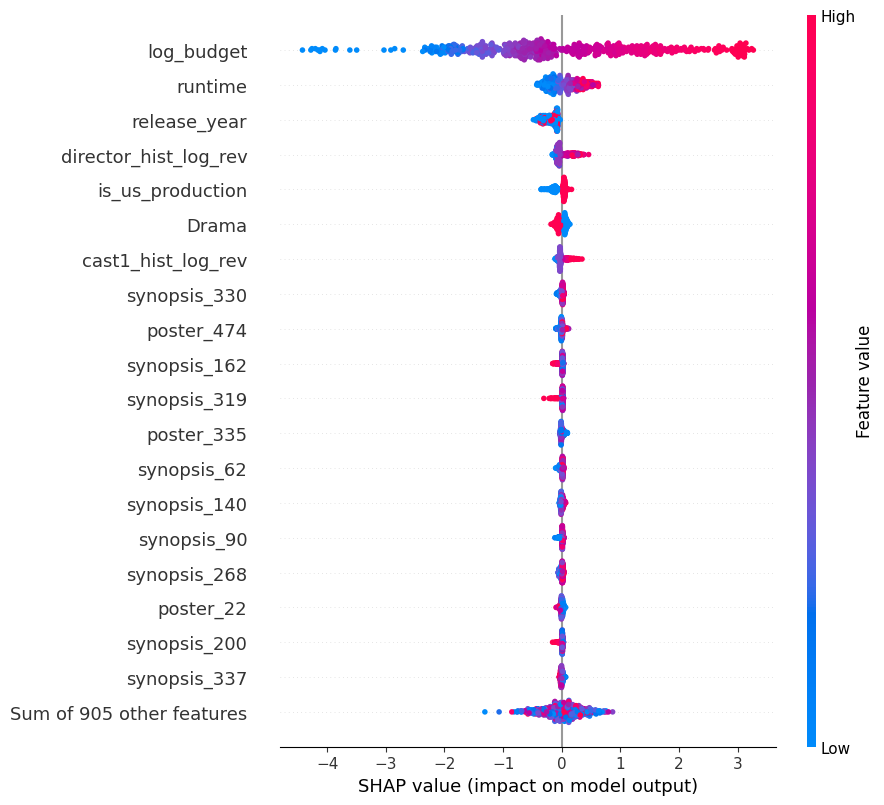

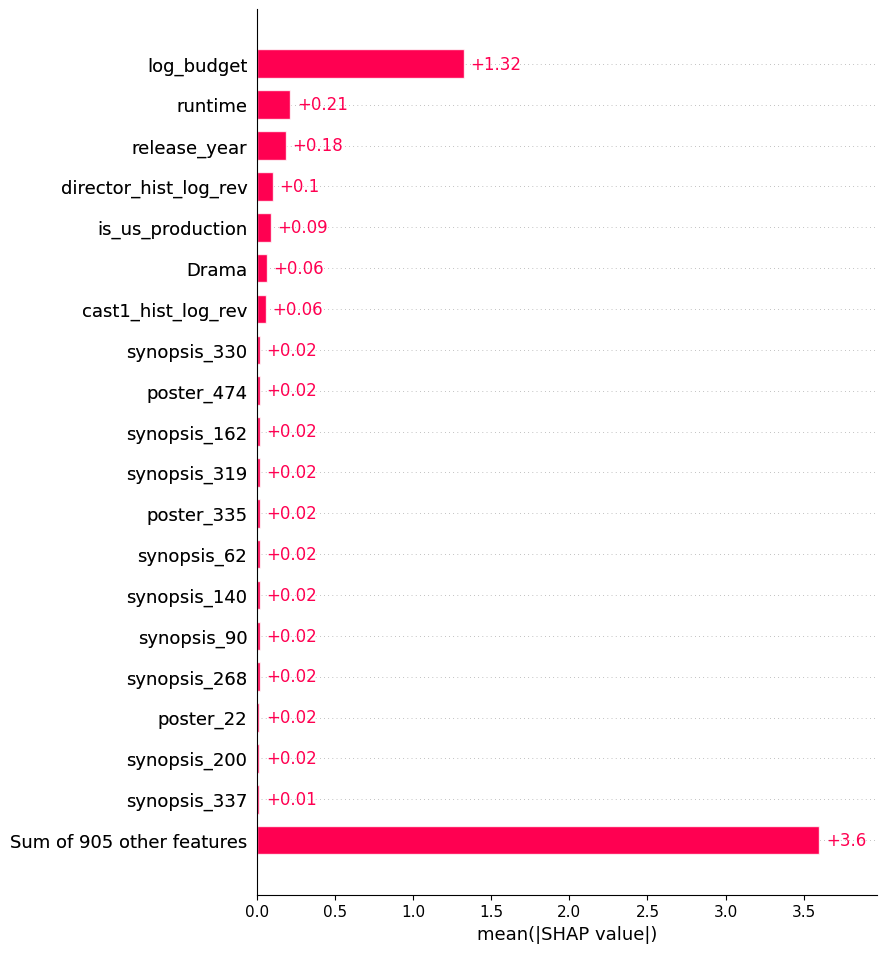

In [50]:
import shap

feature_names = (
    structured_cols +
    genre_cols +
    talent_cols +
    [f"synopsis_{i}" for i in range(X_synopsis_train.shape[1])] +
    [f"poster_{i}" for i in range(X_poster_train.shape[1])]
)

explainer = shap.TreeExplainer(lgb_model)

# pass feature names here
import pandas as pd
X_val_df    = pd.DataFrame(X_val_full[:500], columns=feature_names)
shap_values = explainer(X_val_df)

shap.plots.beeswarm(shap_values, max_display=20)
shap.plots.bar(shap_values, max_display=20)

In [47]:
y_pred_log  = lgb_model.predict(X_test_full)
y_pred_bin  = (np.expm1(y_pred_log) > 1.5 * test_df["budget"].values).astype(int)
y_true_bin  = test_df["profitable"].values

evaluate_classification(y_true_bin, y_pred_bin.astype(float), label="FINAL TEST classification")

FINAL TEST classification — precision: 0.615 | recall: 0.557 | f1: 0.585 | auc: 0.591


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'precision': 0.6153846153846154,
 'recall': 0.5574193548387096,
 'f1': 0.5849695328368314,
 'auc': 0.5906873932967922}

In [48]:
evaluate_regression(y_test, lgb_model.predict(X_test_full), label="FINAL TEST")

FINAL TEST — rmse: 1.7754 | mae: 1.3133 | r2: 0.6520


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'rmse': np.float64(1.7754457266144843),
 'mae': 1.3133081595649103,
 'r2': 0.6519620418527918}